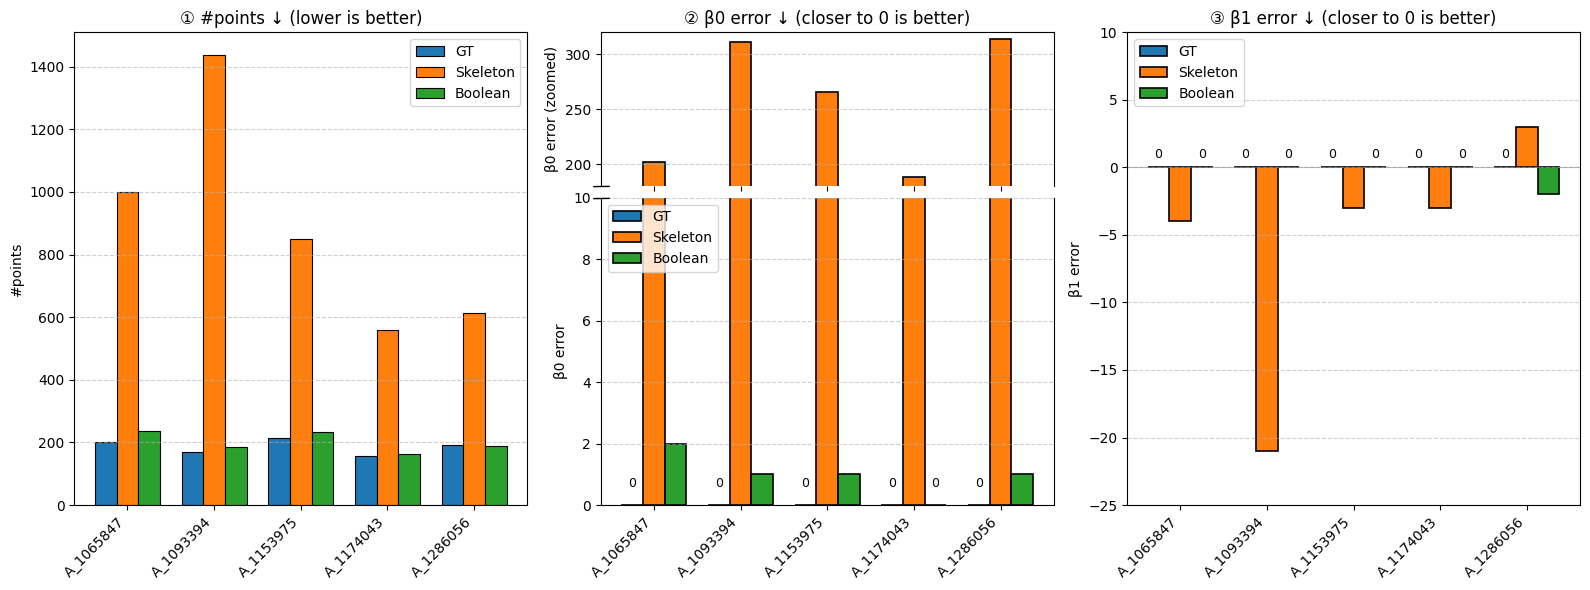

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

# 读取数据
df = pd.read_csv("/mnt/workspace/00_MRCP/topology_betti_comparison.csv")

cases = df['case'].tolist()
gt_points = df['GT_points']
sk_points = df['SK_points']
eb_points = df['EB_points']

# 有符号 β0 误差
gt_beta0 = df['GT_beta0']
sk_beta0 = df['SK_beta0']
eb_beta0 = df['EB_beta0']
sk_beta0_err = sk_beta0 - gt_beta0
eb_beta0_err = eb_beta0 - gt_beta0

# 有符号 β1 误差
gt_beta1 = df['GT_beta1']
sk_beta1 = df['SK_beta1']
eb_beta1 = df['EB_beta1']
sk_beta1_err = sk_beta1 - gt_beta1
eb_beta1_err = eb_beta1 - gt_beta1

x = np.arange(len(cases))
width = 0.25
colors = {'gt': '#1f77b4', 'sk': '#ff7f0e', 'eb': '#2ca02c'}

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], figure=fig)

# ------------------- 子图1：points -------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x - width, gt_points, width, label='GT', color=colors['gt'], edgecolor='k', linewidth=0.8)
ax1.bar(x, sk_points, width, label='Skeleton', color=colors['sk'], edgecolor='k', linewidth=0.8)
ax1.bar(x + width, eb_points, width, label='Boolean', color=colors['eb'], edgecolor='k', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(cases, rotation=45, ha='right')
ax1.set_ylabel('#points')
ax1.set_title('① #points ↓ (lower is better)', fontsize=12)
ax1.legend()
ax1.grid(axis='y', ls='--', alpha=0.6)

# ------------------- 子图2：β0 error（断轴 0-10 / 180-320）-------------------
gs0 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0,1], height_ratios=[1, 2], hspace=0.05)
ax0_top = fig.add_subplot(gs0[0])
ax0_bot = fig.add_subplot(gs0[1], sharex=ax0_top)

ax0_bot.set_ylim(0, 10)
ax0_top.set_ylim(180, 320)

ax0_top.spines['bottom'].set_visible(False)
ax0_bot.spines['top'].set_visible(False)
ax0_top.tick_params(axis='x', labelbottom=False)

ax0_bot.bar(x - width, [0]*len(cases), width, label='GT', color=colors['gt'], edgecolor='k', linewidth=1.2)
ax0_bot.bar(x, sk_beta0_err, width, label='Skeleton', color=colors['sk'], edgecolor='k', linewidth=1.2)
ax0_bot.bar(x + width, eb_beta0_err, width, label='Boolean', color=colors['eb'], edgecolor='k', linewidth=1.2)

ax0_top.bar(x - width, [0]*len(cases), width, color=colors['gt'], edgecolor='k', linewidth=1.2)
ax0_top.bar(x, sk_beta0_err, width, color=colors['sk'], edgecolor='k', linewidth=1.2)
ax0_top.bar(x + width, eb_beta0_err, width, color=colors['eb'], edgecolor='k', linewidth=1.2)

# 断点斜线
d = 0.015
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax0_top.plot(0, 0, transform=ax0_top.transAxes, **kwargs)
ax0_bot.plot(0, 1, transform=ax0_bot.transAxes, **kwargs)

ax0_bot.set_xticks(x)
ax0_bot.set_xticklabels(cases, rotation=45, ha='right')
ax0_bot.set_ylabel('β0 error')
ax0_top.set_ylabel('β0 error (zoomed)')
ax0_bot.legend(loc='upper left')
ax0_top.set_title('② β0 error ↓ (closer to 0 is better)', fontsize=12)
ax0_top.grid(axis='y', ls='--', alpha=0.6)
ax0_bot.grid(axis='y', ls='--', alpha=0.6)

# 标注零值（GT全0）
for i, (g, s, e) in enumerate(zip([0]*len(cases), sk_beta0_err, eb_beta0_err)):
    if g == 0:
        ax0_bot.text(x[i] - width, 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')
    if s == 0:
        ax0_bot.text(x[i], 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')
    if e == 0:
        ax0_bot.text(x[i] + width, 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')

# ------------------- 子图3：β1 error（普通 y 轴，显示负值）-------------------
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(x - width, [0]*len(cases), width, label='GT', color=colors['gt'], edgecolor='k', linewidth=1.2)
ax2.bar(x, sk_beta1_err, width, label='Skeleton', color=colors['sk'], edgecolor='k', linewidth=1.2)
ax2.bar(x + width, eb_beta1_err, width, label='Boolean', color=colors['eb'], edgecolor='k', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(cases, rotation=45, ha='right')
ax2.set_ylabel('β1 error')
ax2.set_title('③ β1 error ↓ (closer to 0 is better)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(axis='y', ls='--', alpha=0.6)
ax2.set_ylim(-25, 10)
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# 标注零值
for i, (g, s, e) in enumerate(zip([0]*len(cases), sk_beta1_err, eb_beta1_err)):
    if g == 0:
        ax2.text(x[i] - width, 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')
    if s == 0:
        ax2.text(x[i], 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')
    if e == 0:
        ax2.text(x[i] + width, 0.5, '0', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()